# Retail Sales Explorer

**Question:** Which markets, months, and products account for positive sales?

This educational portfolio project uses a public UCI dataset. It was developed with AI assistance; review the code and assumptions before presenting it. See `DATA.md` for the dataset citation, license, exact source hash, and transformations.

## 1. Setup
Run every cell in order with Python 3.12 and the project dependencies installed.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.pipeline import main


## 2. Inspect data quality
The raw spreadsheet includes repeated rows, cancellations, and missing customer IDs. We inspect the actual data instead of assuming that metadata guarantee completeness.

In [2]:
from src.data import load_data, clean_sales
raw, source_hash = load_data()
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing": raw.isna().sum()}))
print("Source rows:", len(raw))
sales, audit = clean_sales(raw)
display(pd.Series(audit, name="rows").to_frame())

,dtype,missing
InvoiceNo,str,0
StockCode,str,0
Description,str,1454
Quantity,int64,0
InvoiceDate,datetime64[us],0
UnitPrice,float64,0
CustomerID,float64,135080
Country,str,0


Source rows: 541909


,rows
raw_rows,541909
duplicate_rows,5268
cancellation_or_negative_rows,10587
nonpositive_or_invalid_rows,1176
clean_rows,524878
missing_customer_rows_retained,132186


## 3. Define the metric and query it
Positive sales = quantity × unit price. Cancellations, negative quantities, nonpositive prices and exact duplicates are excluded. Missing customer IDs are kept for sales totals. This is not net revenue, because returns are excluded.

In [3]:
import sqlite3
from src.pipeline import MONTH_SQL
with sqlite3.connect(":memory:") as connection:
    sales[["Month", "Sales", "InvoiceNo"]].to_sql("sales", connection, index=False)
    monthly = pd.read_sql_query(MONTH_SQL, connection)
display(monthly)
assert abs(monthly.sales.sum() - sales.Sales.sum()) < 0.02

,month,sales,orders,line_items
0,2010-12,821452.73,1559,40991
1,2011-01,689811.61,1086,34060
2,2011-02,522545.56,1100,26882
3,2011-03,716215.26,1454,35497
4,2011-04,536968.49,1246,28882
5,2011-05,769296.61,1681,35917
6,2011-06,760547.01,1533,35716
7,2011-07,718076.12,1475,38395
8,2011-08,757841.38,1361,34264
9,2011-09,1056435.19,1837,48900


## 4. Rebuild the results and dashboard
The same pipeline produces the report tables, static chart, and browser data, preventing mismatched numbers.

{
  "audit": {
    "raw_rows": 541909,
    "duplicate_rows": 5268,
    "cancellation_or_negative_rows": 10587,
    "nonpositive_or_invalid_rows": 1176,
    "clean_rows": 524878,
    "missing_customer_rows_retained": 132186
  },
  "overall": {
    "sales": 10642110.8,
    "orders": 19960,
    "customers": 4338,
    "line_items": 524878,
    "aov": 533.17,
    "products": [
      {
        "code": "DOT",
        "name": "DOTCOM POSTAGE",
        "sales": 206248.77
      },
      {
        "code": "22423",
        "name": "REGENCY CAKESTAND 3 TIER",
        "sales": 174156.54
      },
      {
        "code": "23843",
        "name": "PAPER CRAFT , LITTLE BIRDIE",
        "sales": 168469.6
      },
      {
        "code": "85123A",
        "name": "WHITE HANGING HEART T-LIGHT HOLDER",
        "sales": 104462.75
      },
      {
        "code": "47566",
        "name": "PARTY BUNTING",
        "sales": 99445.23
      },
      {
        "code": "85099B",
        "name": "JUMBO BAG RED RETROS

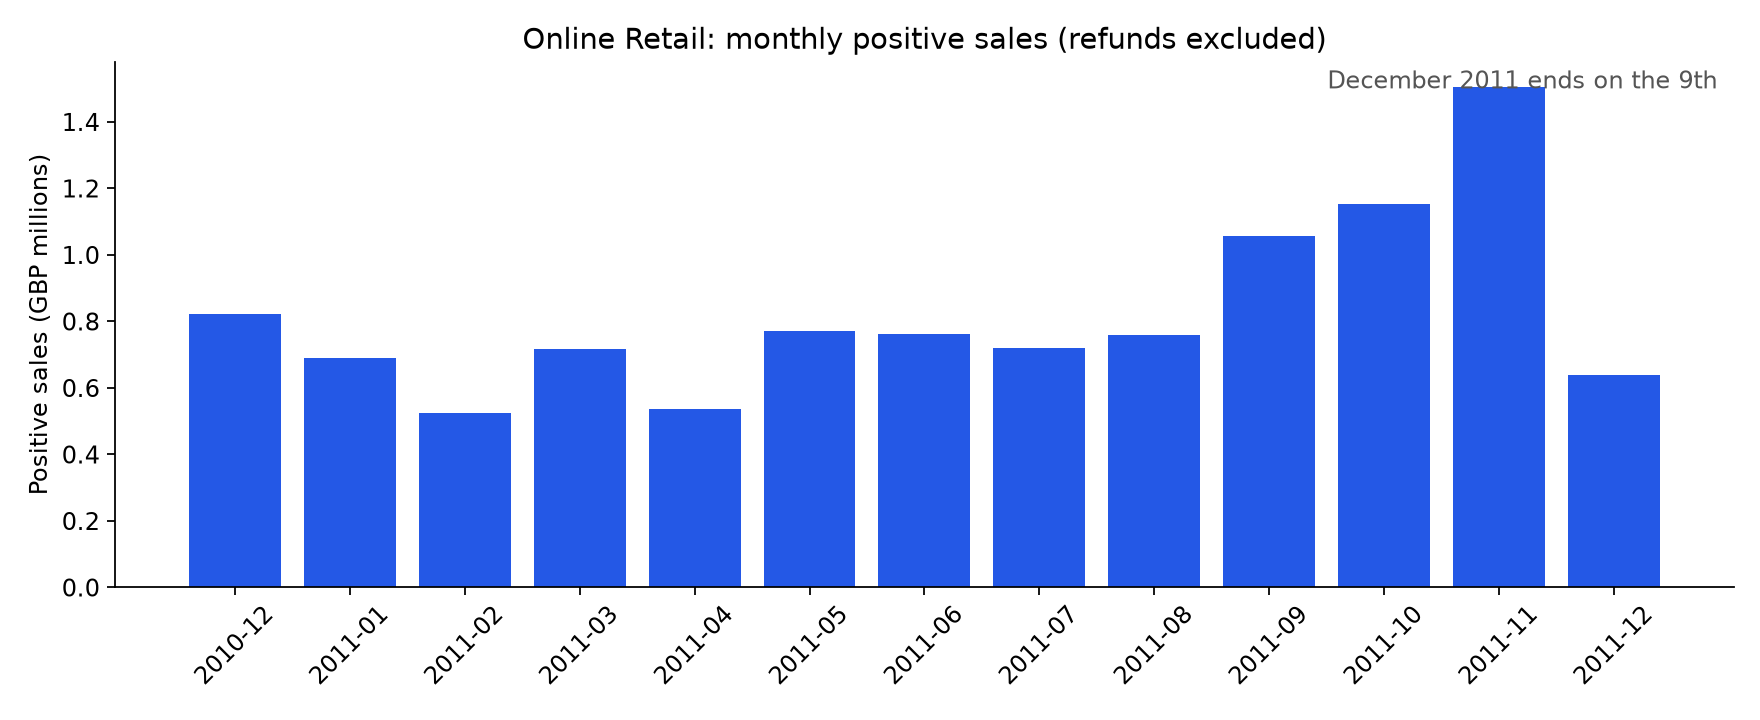

In [4]:
result = main()
display(Image(filename=str(ROOT / "reports/monthly_sales.png")))

## 5. Explore market concentration
The UK dominates this UK-based retailer. Compare shares before comparing market growth. December 2011 is a partial month and must be flagged.

In [5]:
market = sales.groupby("Country").Sales.sum().sort_values(ascending=False).to_frame("positive_sales_gbp")
market["share_percent"] = market.positive_sales_gbp / market.positive_sales_gbp.sum() * 100
display(market.head(10).round(2))

,positive_sales_gbp,share_percent
Country,,
United Kingdom,9001744.09,84.59
Netherlands,285446.34,2.68
EIRE,283140.52,2.66
Germany,228678.40,2.15
France,209625.37,1.97
Australia,138453.81,1.30
Spain,61558.56,0.58
Switzerland,57067.60,0.54
Belgium,41196.34,0.39


## 6. Conclusions and next work
The analysis measures positive transaction value, not profit or causal effects. Service codes such as postage may rank among top items. Deduplication can remove legitimate identical purchases; validate that business rule before production use.

**Try it:** add a separate returns analysis, compare complete months, and quantify how keeping duplicates changes the totals.